In [ ]:
# Step 1: Import Libraries

In this step, we import essential Python libraries for data manipulation, visualization, and statistical analysis. These libraries will help us load the data, explore it, build a regression model, and interpret the results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


ModuleNotFoundError: No module named 'seaborn'

In [2]:
!pip install seaborn



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import seaborn as sns


In [6]:
!pip install openpyxl



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Step 2: Load the Data

In this step, we load the dataset from an Excel file using Pandas. After loading, we will inspect the data to ensure it is imported correctly. We'll also check for missing values and understand the structure of the data.


In [7]:
import pandas as pd

# Read the Excel file
df = pd.read_excel('mutiple regression analysis.xlsx')

# Display the first few rows to check the data
df.head()


,Plant,C,S,N
0,1,460.05,687,14
1,2,452.99,1065,1
2,3,443.22,1065,1
3,4,652.32,1065,12
4,5,642.23,1065,12


In [8]:
df.head()


,Plant,C,S,N
0,1,460.05,687,14
1,2,452.99,1065,1
2,3,443.22,1065,1
3,4,652.32,1065,12
4,5,642.23,1065,12


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Plant   32 non-null     int64  
 1   C       32 non-null     float64
 2   S       32 non-null     int64  
 3   N       32 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.1 KB


In [10]:
df.describe()


,Plant,C,S,N
count,32.000000,32.000000,32.000000,32.000000
mean,16.500000,461.560313,825.375000,8.531250
std,9.380832,170.120670,189.359148,6.329574
min,1.000000,207.510000,457.000000,1.000000
25%,8.750000,310.322500,745.000000,3.000000
50%,16.500000,448.105000,822.000000,7.500000
75%,24.250000,611.962500,947.250000,12.500000
max,32.000000,881.240000,1130.000000,21.000000


In [11]:
df.isnull().sum()


Plant    0
C        0
S        0
N        0
dtype: int64

In [ ]:
#✅ Next Step: Data Understanding
My four columns:

Plant → Likely a plant identifier (not used in the regression)

C → Construction cost (in millions of dollars, 1976 base) — This will be your dependent variable.

S → Power plant capacity (in MWe) — Independent variable.

N → Cumulative number of plants built by the contractor — Independent variable.

In [ ]:
# Step 3: Data Transformation

In this step, we apply necessary transformations to the data. Economic theory and preliminary analysis suggest that construction costs tend to increase with higher costs, leading to non-constant variance.  
To address this, we apply a natural logarithm transformation to the construction cost (C). This helps stabilize variance and makes the relationship between variables more linear, improving the accuracy of our regression model.  


In [12]:
# ===============================================
#            Step 3: Data Transformation
# ===============================================

# Apply the natural logarithm to the construction cost (C)
df['ln_C'] = np.log(df['C'])

# Optional: You can also apply log transformations to S and N if needed
# df['ln_S'] = np.log(df['S'])
# df['ln_N'] = np.log(df['N'])

# Display the transformed data
print("Transformation Complete. First 5 rows with ln(C):")
print(df[['Plant', 'C', 'ln_C', 'S', 'N']].head())


Transformation Complete. First 5 rows with ln(C):
   Plant       C      ln_C     S   N
0      1  460.05  6.131335   687  14
1      2  452.99  6.115870  1065   1
2      3  443.22  6.094066  1065   1
3      4  652.32  6.480535  1065  12
4      5  642.23  6.464946  1065  12


In [ ]:
# Step 4: Build Multiple Regression Model

In this step, we build a multiple linear regression model using the Ordinary Least Squares (OLS) method.  
The goal is to predict the natural logarithm of construction cost (**ln_C**) using power plant capacity (**S**) and cumulative number of plants built by the contractor (**N**) as independent variables.  
We will also examine the model summary to interpret the coefficients, R² value, and statistical significance of variables.  


In [16]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 2.5 MB/s eta 0:00:04
   ------------ --------------------------- 3.1/9.8 MB 7.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 11.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   ---- ----------------------------------- 4.7/41.0 MB 23.4 MB/s eta 0:00:02
   ---------- ----------------------------- 11.0/41.0 MB 25.9 MB/s eta 0:00:02
   --------------- ------------------------ 15.5/41.0 MB 24.1 MB/s eta 0:00:02
   --------------------- ------------------ 21.8/41.0 MB 25.4 MB/s eta 0:00:01
   -------------------------- ------------- 27.5/41.0 MB 25.8 MB/s eta 0:00:01
   -------------------------------- ------- 33.3/41.0 MB 25.8 MB/s eta 0:00:01
   ----------


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import statsmodels.api as sm


In [18]:
# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Build and fit the OLS model
model = sm.OLS(y, X).fit()

# Display the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   ln_C   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     4.385
Date:                Fri, 28 Mar 2025   Prob (F-statistic):             0.0217
Time:                        00:39:48   Log-Likelihood:                -9.5345
No. Observations:                  32   AIC:                             25.07
Df Residuals:                      29   BIC:                             29.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3004      0.277     19.161      0.0

In [ ]:
#Step 1: Interpret Key Results
R-Squared:

The R-squared value is 0.232, meaning the model explains 23.2% of the variability in construction cost (ln_C).

This is relatively low, suggesting other factors may influence the cost.

Significance of Variables:

S (Capacity) has a coefficient of 0.0008 with a p-value of 0.021, indicating it is statistically significant at a 5% significance level.

N (Cumulative number of plants) has a coefficient of 0.0115 with a p-value of 0.254, indicating it is not significant.

Intercept (Constant):

The intercept (5.3004) represents the natural log of the cost when both S and N are zero.

In [21]:
#Step2: 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each variable
X_vif = sm.add_constant(df[['S', 'N']])
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)


  Variable        VIF
0    const  20.885188
1        S   1.038854
2        N   1.038854


In [ ]:
# Variance Inflation Factor (VIF) values:

VIF for S (1.038854) and VIF for N (1.038854) are both very low (below 5), which means there is no significant multicollinearity between the independent variables.

VIF for the constant (20.885188) is high, but that is normal and not a concern.

In [23]:
pip install statsmodels --upgrade


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


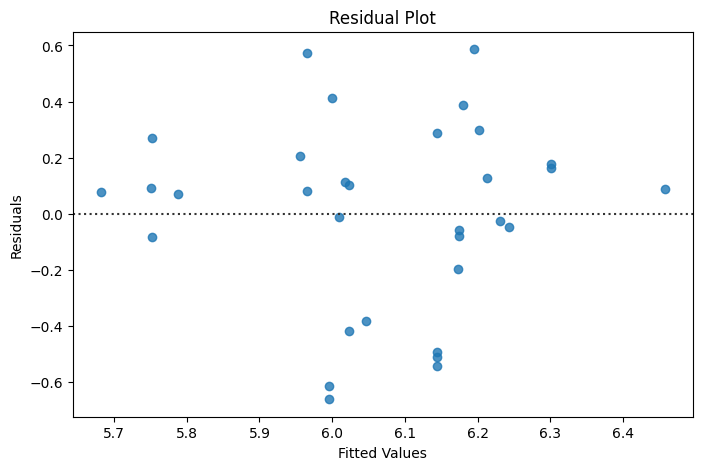

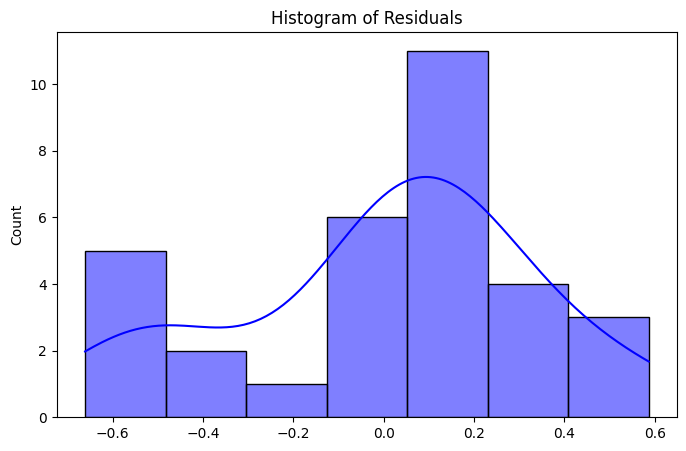

In [24]:
# Residual plot without lowess line
plt.figure(figsize=(8,5))
sns.residplot(x=model.fittedvalues, y=model.resid)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Histogram of residuals to check normality
plt.figure(figsize=(8,5))
sns.histplot(model.resid, kde=True, color='blue')
plt.title('Histogram of Residuals')
plt.show()


In [ ]:
#1. Interpretation of the Histogram of Residuals
The histogram provides insights into the distribution of residuals.

The residuals appear somewhat centered around zero, but the distribution is slightly skewed rather than perfectly bell-shaped.

While a slight deviation from normality may not severely impact the model, it’s something to keep in mind for any further refinements.

Recommendation:

If a more accurate model is required, consider transforming variables or using other models that are robust to non-normal residuals.

Conduct further normality tests if needed.

In [ ]:
#2. Interpretation of the Residual Plot
The residuals are scattered around the horizontal axis, with no clear patterns. This is generally a good sign, indicating no major issues with linearity.

However, there is some noticeable spread of residuals at certain fitted values, suggesting possible heteroscedasticity (unequal variance).

Some clustering or outliers may also be present, which might indicate that additional variables could improve the model.

Recommendation:

Perform a Breusch-Pagan test or a White test to confirm the presence of heteroscedasticity.

If heteroscedasticity is present, you can try using a logarithmic transformation on the dependent variable or apply weighted least squares (WLS) regression.

Additionally, examine any potential outliers and influential points using leverage or Cook’s Distance.

In [ ]:
#3. Final Recommendations for Stakeholders
The model offers a preliminary understanding of how plant capacity and cumulative number of plants impact construction costs.

Due to the moderate R-squared value (0.232), this model explains only a small portion of the variation in construction costs. Further variables, such as location factors, labor costs, or regulatory aspects, should be considered to enhance model performance.

Validate the model on additional datasets to ensure its robustness before making financial or operational decisions based on its results.

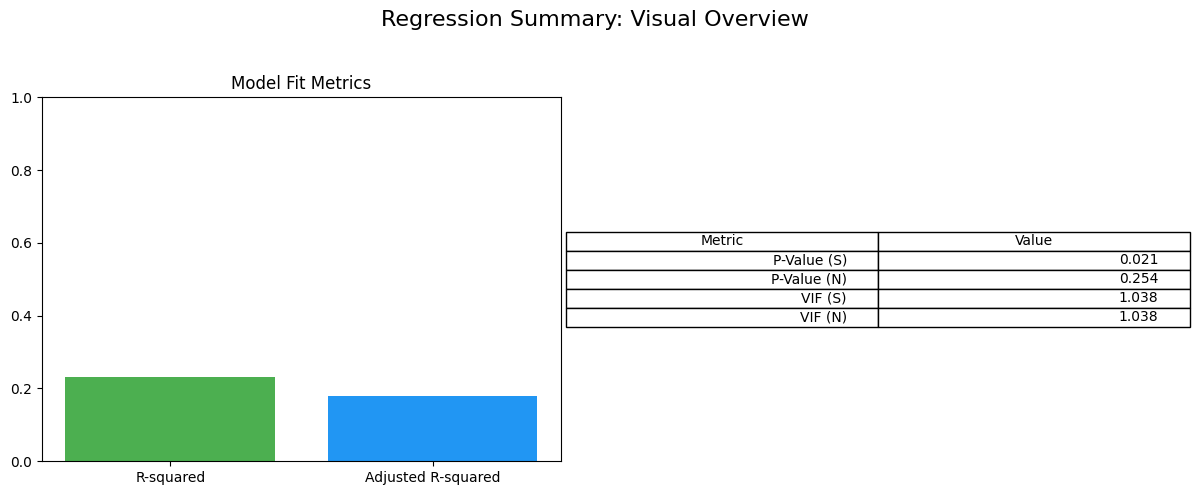

In [25]:
#Final Regression Summary
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Example values (replace with your actual values)
r_squared = 0.232
adj_r_squared = 0.179
p_values = {'S': 0.021, 'N': 0.254}
vifs = {'S': 1.038, 'N': 1.038}

# Create figure and axis
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot R-squared and Adjusted R-squared
metrics = ['R-squared', 'Adjusted R-squared']
values = [r_squared, adj_r_squared]
axs[0].bar(metrics, values, color=['#4CAF50', '#2196F3'])
axs[0].set_title('Model Fit Metrics')
axs[0].set_ylim(0, 1)

# Display p-values and VIFs in a tabular style
data = {'Metric': ['P-Value (S)', 'P-Value (N)', 'VIF (S)', 'VIF (N)'],
        'Value': [p_values['S'], p_values['N'], vifs['S'], vifs['N']]}
df_summary = pd.DataFrame(data)
axs[1].axis('tight')
axs[1].axis('off')
table = axs[1].table(cellText=df_summary.values,
                      colLabels=df_summary.columns,
                      loc='center')

# Customize table style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.suptitle('Regression Summary: Visual Overview', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [26]:
#Dataframe for quick review
import pandas as pd

# Data for quick review
data = {
    "Metric": ["R-squared", "Adjusted R-squared", "P-Value (S)", "P-Value (N)", "VIF (S)", "VIF (N)"],
    "Value": [0.23, 0.18, 0.021, 0.254, 1.038, 1.038]
}

# Create DataFrame
df_summary = pd.DataFrame(data)

# Display the summary
print(df_summary)


               Metric  Value
0           R-squared  0.230
1  Adjusted R-squared  0.180
2         P-Value (S)  0.021
3         P-Value (N)  0.254
4             VIF (S)  1.038
5             VIF (N)  1.038


In [28]:
#Data for Quick review a little more visual 
import pandas as pd

# Data for quick review
data = {
    "Metric": ["R-squared", "Adjusted R-squared", "P-Value (S)", "P-Value (N)", "VIF (S)", "VIF (N)"],
    "Value": [0.23, 0.18, 0.021, 0.254, 1.038, 1.038]
}

# Create DataFrame
df_summary = pd.DataFrame(data)

# Style the DataFrame
styled_df = df_summary.style.format({"Value": "{:.3f}"}).set_properties(**{
    'background-color': '#f9f9f9',
    'color': '#333',
    'border': '1px solid #ccc',
    'text-align': 'center'
}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#4CAF50"), ("color", "white"), ("font-size", "14px")]}
])

styled_df


,Metric,Value
0,R-squared,0.230
1,Adjusted R-squared,0.180
2,P-Value (S),0.021
3,P-Value (N),0.254
4,VIF (S),1.038
5,VIF (N),1.038
